In [1]:
import re
import glob
import matplotlib.pyplot as plt

BASE_DIR = "/home/anthony/cs285-rl/hw2"

In [2]:
def read_wandb_history(run_dir):
    """Read Train_EnvstepsSoFar and Train_AverageReturn from the output.log file."""
    log_files = glob.glob(f"{BASE_DIR}/{run_dir}/wandb/run-*/files/output.log")
    if not log_files:
        raise FileNotFoundError(f"No output.log found in {run_dir}")

    with open(log_files[0]) as f:
        text = f.read()

    steps = []
    returns = []
    for block in text.split("Iteration ")[1:]:
        m_steps = re.search(r"Train_EnvstepsSoFar : ([\d.]+)", block)
        m_ret = re.search(r"Train_AverageReturn : ([\d.]+)", block)
        if m_steps and m_ret:
            steps.append(int(float(m_steps.group(1))))
            returns.append(float(m_ret.group(1)))

    return steps, returns

In [3]:
# Map experiment names to their directories (from experiment-explanation.md)
small_batch_experiments = {
    "cartpole":        "experiments/tmpppx4f5as",
    "cartpole_rtg":    "experiments/tmp5ph868xb",
    "cartpole_na":     "experiments/tmpv330eysd",
    "cartpole_rtg_na": "experiments/tmpvn030yav",
}

large_batch_experiments = {
    "cartpole_lb":        "experiments/tmpe4yjh6yg",
    "cartpole_lb_rtg":    "experiments/tmpe683v6_9",
    "cartpole_lb_na":     "experiments/tmp_vafnug2",
    "cartpole_lb_rtg_na": "experiments/tmp3gxvylyv",
}

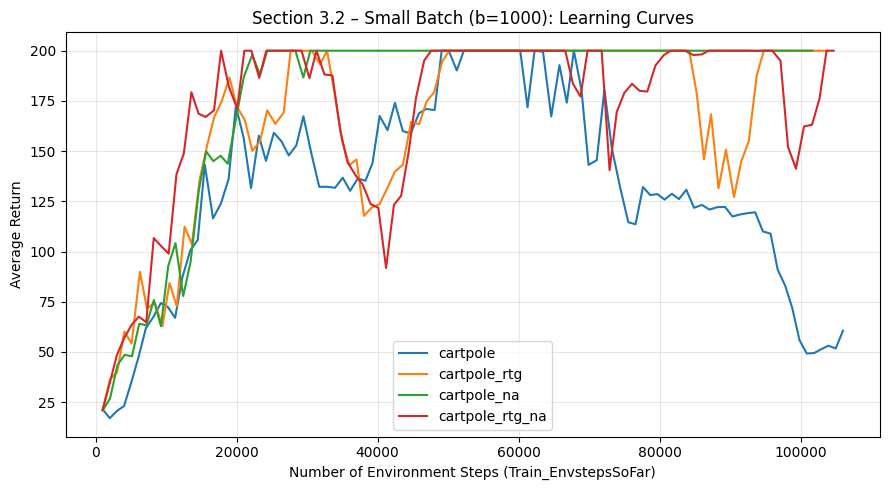

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

for name, path in small_batch_experiments.items():
    steps, returns = read_wandb_history(path)
    ax.plot(steps, returns, label=name)

ax.set_xlabel("Number of Environment Steps (Train_EnvstepsSoFar)")
ax.set_ylabel("Average Return")
ax.set_title("Section 3.2 – Small Batch (b=1000): Learning Curves")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

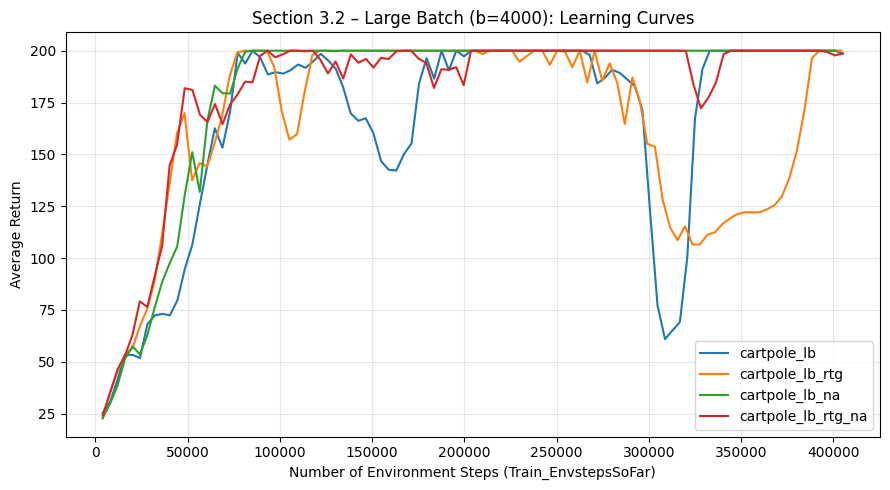

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

for name, path in large_batch_experiments.items():
    steps, returns = read_wandb_history(path)
    ax.plot(steps, returns, label=name)

ax.set_xlabel("Number of Environment Steps (Train_EnvstepsSoFar)")
ax.set_ylabel("Average Return")
ax.set_title("Section 3.2 – Large Batch (b=4000): Learning Curves")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()